In [6]:
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

g = 9.8

# 【学習データ】0秒〜3秒
t_train = np.linspace(0, 3, 100)
y_train = 0.5 * g * (t_train**2) - 0.5 * t_train

# 【テストデータ】未知の領域（4秒〜5秒）
end_point = 100
t_test = np.linspace(4, end_point, 20)
y_test = 0.5 * g * (t_test**2) - 0.5 * t_test

X_train = t_train.reshape(-1, 1)
X_test = t_test.reshape(-1, 1)

# ==========================================
# 【修正版】PI-LightGBMの正しい学習方法（残差学習）
# ==========================================
# 1. 物理法則によるベース予測
physics_train = 0.5 * g * (t_train**2)
physics_test = 0.5 * g * (t_test**2)

# 2. AIが学習すべき「ターゲット」を、実際の値ではなく「物理法則とのズレ（残差）」にする
residual_train = y_train - physics_train

# 3. 学習
model_normal = lgb.LGBMRegressor(n_estimators=50, random_state=42, verbose=-1)
model_pi = lgb.LGBMRegressor(n_estimators=50, random_state=42, verbose=-1)

# 普通のLightGBMは「直接 y」を学習
model_normal.fit(X_train, y_train)

# PI-LightGBMは「残差」のみを学習
model_pi.fit(X_train, residual_train)

# ==========================================
# 予測フェーズ
# ==========================================
# 普通のLightGBMはそのまま予測
pred_normal = model_normal.predict(X_test)

# PI-LightGBMの予測 ＝ 「物理法則ベース」＋「AIが予測した残差」
pred_pi_residual = model_pi.predict(X_test)
pred_pi_final = physics_test + pred_pi_residual

# ==========================================
# 結果の比較
# ==========================================
print(f"未知領域(4-{end_point}秒)のRMSE")
print(f"普通のLightGBM : {np.sqrt(mean_squared_error(y_test, pred_normal)):.2f}")
print(f"PI-LightGBM    : {np.sqrt(mean_squared_error(y_test, pred_pi_final)):.2f}")


未知領域(4-100秒)のRMSE
普通のLightGBM : 23123.93
PI-LightGBM    : 28.64


/home/tm/sandbox_outputlab/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/tm/sandbox_outputlab/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/tm/sandbox_outputlab/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/tm/sandbox_outputlab/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


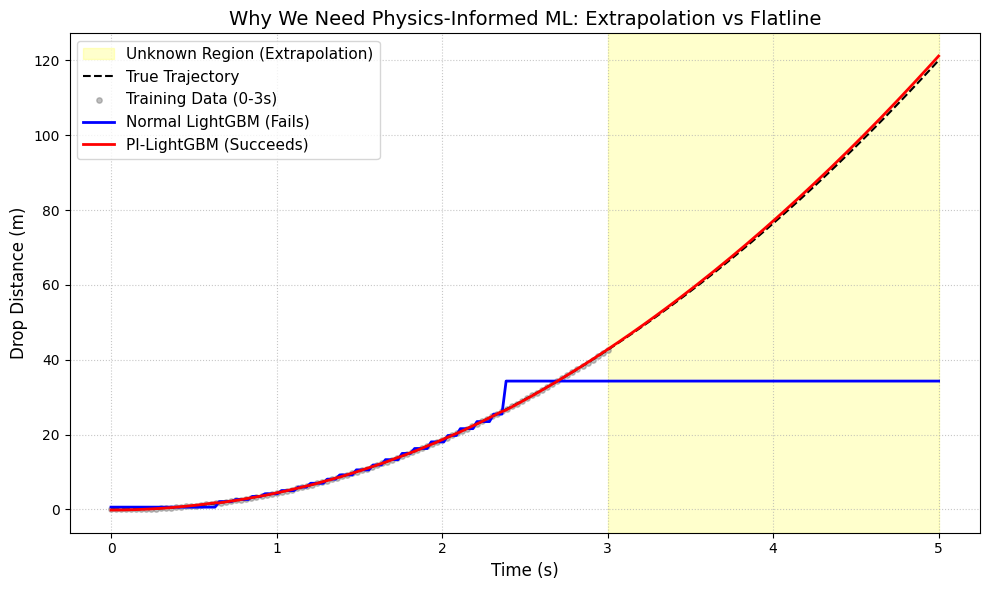

In [7]:
import matplotlib.pyplot as plt

# ==========================================
# 4. グラフ描画用の予測（0秒〜5秒まで連続で予測させる）
# ==========================================
t_all = np.linspace(0, 5, 200)
X_all = t_all.reshape(-1, 1)

# 普通のLightGBMの予測
pred_normal = model_normal.predict(X_all)

# PI-LightGBMの予測（物理法則ベース ＋ AIが予測した残差）
physics_all = 0.5 * g * (t_all**2)
pred_pi_residual = model_pi.predict(X_all)
pred_pi_final = physics_all + pred_pi_residual

# 真の軌跡（正解）
y_all_true = 0.5 * g * (t_all**2) - 0.5 * t_all

# ==========================================
# 5. Matplotlibによる視覚化
# ==========================================
plt.figure(figsize=(10, 6))

# 背景色で「未知の領域（外挿）」を強調
plt.axvspan(3, 5, color="yellow", alpha=0.2, label="Unknown Region (Extrapolation)")

# 正解の軌跡と学習データ
plt.plot(t_all, y_all_true, label="True Trajectory", color="black", linestyle="--")
plt.scatter(
    t_train, y_train, label="Training Data (0-3s)", color="gray", alpha=0.5, s=15
)

# AIモデルの予測結果
plt.plot(t_all, pred_normal, label="Normal LightGBM (Fails)", color="blue", linewidth=2)
plt.plot(t_all, pred_pi_final, label="PI-LightGBM (Succeeds)", color="red", linewidth=2)

# グラフの装飾
plt.title("Why We Need Physics-Informed ML: Extrapolation vs Flatline", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Drop Distance (m)", fontsize=12)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.7)

# グラフの表示
plt.tight_layout()
plt.show()
